In [32]:
from pathlib import Path
import sys
import warnings

import joblib
import pandas as pd
from scipy import sparse

from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.model_selection import ParameterGrid, StratifiedKFold, cross_val_score
from sklearn.naive_bayes import ComplementNB
from sklearn.svm import LinearSVC

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
X_TRAIN_PATH = DATA_DIR / "X_train.npz"
X_TEST_PATH = DATA_DIR / "X_test.npz"
Y_TRAIN_PATH = DATA_DIR / "y_train.csv"
Y_TEST_PATH = DATA_DIR / "y_test.csv"
LABEL_ENCODER_PATH = DATA_DIR / "label_encoder.joblib"
BEST_MODEL_PATH = DATA_DIR / "best_sentiment_model.joblib"
MODEL_RESULTS_PATH = DATA_DIR / "model_results.csv"
RANDOM_STATE = 42
MAX_GENERALIZATION_GAP = 0.08

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

warnings.filterwarnings("ignore")


 ------------------------------------------------------------------
 1. Load feature-engineered data
 ------------------------------------------------------------------


In [33]:
X_train = sparse.load_npz(X_TRAIN_PATH)
X_test = sparse.load_npz(X_TEST_PATH)
y_train_df = pd.read_csv(Y_TRAIN_PATH)
y_test_df = pd.read_csv(Y_TEST_PATH)
y_train = y_train_df["label"]
y_test = y_test_df["label"]
le = joblib.load(LABEL_ENCODER_PATH)

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("Classes:", list(le.classes_))
print("Train distribution:")
print(y_train.value_counts(normalize=True).sort_index().round(3))
print("Test distribution:")
print(y_test.value_counts(normalize=True).sort_index().round(3))


X_train: (71742, 40000)  X_test: (17936, 40000)
Classes: ['Negative', 'Neutral', 'Positive']
Train distribution:
label
0    0.360
1    0.313
2    0.328
Name: proportion, dtype: float64
Test distribution:
label
0    0.360
1    0.312
2    0.328
Name: proportion, dtype: float64


 ------------------------------------------------------------------
 2. Tune candidate text classifiers for generalization
Each algorithm is tuned internally, then only the best generalized parameter set for each model is shown: Linear SVM, Logistic Regression, and Complement Naive Bayes.
 ------------------------------------------------------------------


In [ ]:
from sklearn.model_selection import StratifiedKFold, ParameterGrid, cross_val_score
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

candidate_grids = {

    "Linear SVM": {
        "estimator": LinearSVC(
            class_weight="balanced",
            random_state=RANDOM_STATE
        ),
        "params": {
            "C": [0.01, 0.02, 0.03, 0.05, 0.075, 0.1]
        },
    },

    "Logistic Regression": {
        "estimator": LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=1,
        ),
        "params": {
            "C": [0.1, 0.25, 0.5]
        },
    },

    "Complement Naive Bayes": {
        "estimator": ComplementNB(),
        "params": {
            "alpha": [0.1, 0.5, 1.0]
        },
    },
}

all_results = []
trained_models = {}

for name, cfg in candidate_grids.items():

    print(f"Tuning {name} ...")

    for params in ParameterGrid(cfg["params"]):

        model = clone(cfg["estimator"]).set_params(**params)

        # Cross-validation (optional but useful)
        cv_scores = cross_val_score(
            model,
            X_train,
            y_train,
            scoring="f1_macro",
            cv=cv,
            n_jobs=1,
        )

        # Train
        model.fit(X_train, y_train)

        # Predictions
        train_preds = model.predict(X_train)
        test_preds = model.predict(X_test)

        # Metrics
        train_acc = accuracy_score(y_train, train_preds)
        test_acc = accuracy_score(y_test, test_preds)

        precision = precision_score(
            y_test,
            test_preds,
            average="macro"
        )

        recall = recall_score(
            y_test,
            test_preds,
            average="macro"
        )

        f1 = f1_score(
            y_test,
            test_preds,
            average="macro"
        )

        model_key = f"{name} | {params}"
        trained_models[model_key] = model

        all_results.append({
            "model": name,
            "train_accuracy": train_acc,
            "test_accuracy": test_acc,
            "precision": precision,
            "recall": recall,
            "f1_score": f1,
            "best_params": params,
            "model_key": model_key,
        })


all_results_df = pd.DataFrame(all_results)

best_rows = []

for model_name, model_results in all_results_df.groupby("model"):

    best_row = model_results.sort_values(
        by="test_accuracy",
        ascending=False
    ).iloc[0]

    best_rows.append(best_row)

results_df = pd.DataFrame(best_rows)

results_df = results_df.sort_values(
    by="test_accuracy",
    ascending=False
).reset_index(drop=True)

# Save key of best overall model
best_model_key = results_df.iloc[0]["model_key"]

# Retrieve trained model
best_model = trained_models[best_model_key]

# Remove internal column before displaying
results_df = results_df.drop(columns=["model_key"])

results_df

Tuning Linear SVM ...
Tuning Logistic Regression ...
Tuning Complement Naive Bayes ...


,model,train_accuracy,test_accuracy,precision,recall,f1_score,best_params
0,Linear SVM,0.769549,0.680029,0.680640,0.678328,0.679215,{'C': 0.075}
1,Logistic Regression,0.771264,0.676015,0.677812,0.675220,0.676061,{'C': 0.5}
2,Complement Naive Bayes,0.688634,0.640778,0.641432,0.634887,0.632440,{'alpha': 0.1}


 ------------------------------------------------------------------
 3. Compare models visually
 ------------------------------------------------------------------


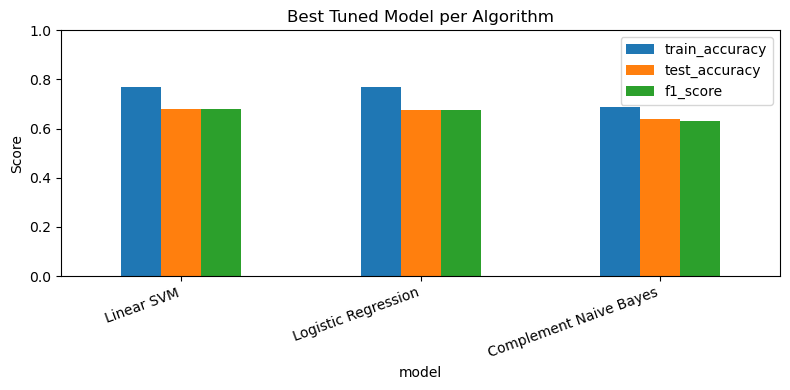

In [39]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
results_df.set_index("model")[["train_accuracy", "test_accuracy", "f1_score"]].plot(kind="bar", ax=ax)
ax.set_title("Best Tuned Model per Algorithm")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


 ------------------------------------------------------------------
 4. Save the best model for evaluation
 ------------------------------------------------------------------


In [40]:
best_model = trained_models[best_model_key]

joblib.dump(best_model, BEST_MODEL_PATH)

results_df.to_csv(MODEL_RESULTS_PATH, index=False)

print(f"Best model: {results_df.iloc[0]['model']}")
print(f"Best parameters: {results_df.iloc[0]['best_params']}")
print(f"Training Accuracy: {results_df.iloc[0]['train_accuracy']:.4f}")
print(f"Testing Accuracy: {results_df.iloc[0]['test_accuracy']:.4f}")
print(f"Precision: {results_df.iloc[0]['precision']:.4f}")
print(f"Recall: {results_df.iloc[0]['recall']:.4f}")
print(f"F1 Score: {results_df.iloc[0]['f1_score']:.4f}")

print(f"\nSaved model to {BEST_MODEL_PATH}")
print(f"Saved model comparison to {MODEL_RESULTS_PATH}")

Best model: Linear SVM
Best parameters: {'C': 0.075}
Training Accuracy: 0.7695
Testing Accuracy: 0.6800
Precision: 0.6806
Recall: 0.6783
F1 Score: 0.6792

Saved model to /Users/tiyasharma/Desktop/TIYA/AI ML/Project /Comments Sentimental Analysis  copy 2/data/best_sentiment_model.joblib
Saved model comparison to /Users/tiyasharma/Desktop/TIYA/AI ML/Project /Comments Sentimental Analysis  copy 2/data/model_results.csv
